Arrivato al punto B: inizio presa dallo scaffale
Braccio sopra il pacco: scendo per prendere
Pacco preso: porto il braccio in posizione di non ingombro
cargo_event: {'zone': 'B_shelf_load', 'action': 'load', 'payload_before_kg': 0, 'payload_after_kg': 15.0, 'total_mass_kg': 25.0}
Braccio sicuro: parto verso il punto A per scaricare
Arrivato al punto A: preparo lo scarico
Braccio sopra la zona di scarico: scendo
Pacco scaricato: riporto il braccio in posizione sicura
cargo_event: {'zone': 'A_unload', 'action': 'unload', 'payload_before_kg': 15.0, 'payload_after_kg': 0, 'total_mass_kg': 10}
Missione completata


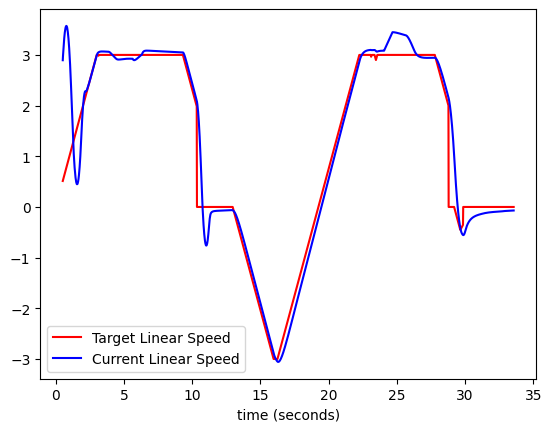

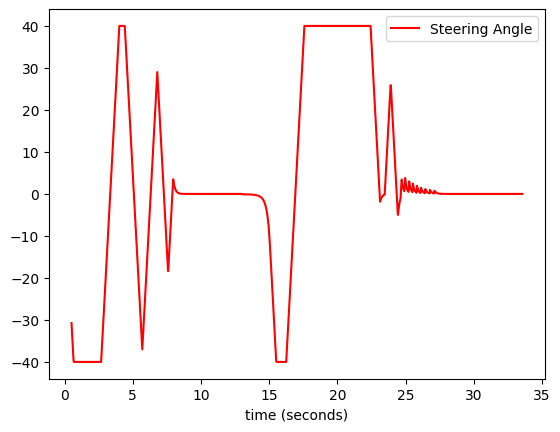

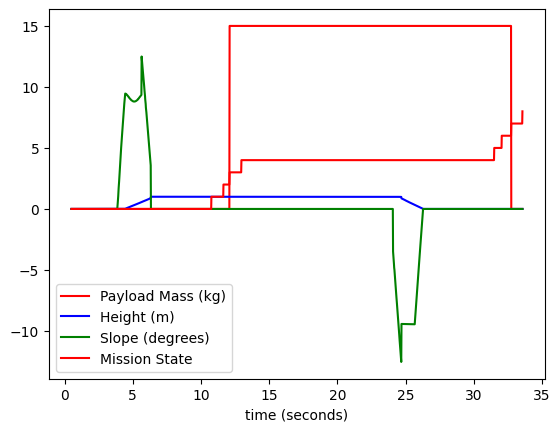

A unload: (0.0, 0.0) B shelf/load: (0.0, -25.0) zone_radius_m: 0.35
cargo_events: [{'zone': 'B_shelf_load', 'action': 'load', 'payload_before_kg': 0, 'payload_after_kg': 15.0, 'total_mass_kg': 25.0}, {'zone': 'A_unload', 'action': 'unload', 'payload_before_kg': 15.0, 'payload_after_kg': 0, 'total_mass_kg': 10}]
final_pose: (-0.002182780617648411, -0.24335351195696797, 0.0, 1.5618266349403551, 0.0) final_error_from_A_m: 0.2433633010809455
payload_kg: 0 reached_A: True mission_complete: True


In [1]:
import sys
import math
sys.path.append("../")

#
# TO BE USED WITH the Godot project in ../ackermann
# Missione completa:
# 1) il carrello parte dal punto A
# 2) va al punto B, dove c'e' lo scaffale
# 3) il braccio prende il pacco
# 4) il braccio va in posizione di non ingombro
# 5) il carrello torna al punto A
# 6) il braccio si abbassa e scarica il pacco
#

from lib.system.cart import *
from lib.dds.dds import *
from lib.utils.time import *
from lib.data.dataplot import *
from manipulator_control import *
from ackermann_mission import AckermannMissionConfig, AckermannMissionController

# -------------------------
# DDS / Godot middleware
# -------------------------
dds = DDS()
dds.start()
dds.subscribe(['tick', 'TerrainHeight', 'TerrainSlope'])

# -------------------------
# Robot: carrello + braccio
# -------------------------
arm = FourJointsManipulatorControl()
terrain = MeasuredTerrainProfile()
cart2d = AckermannSlopeLoad(
    cart_mass=10,
    friction=0.8,
    wheel_radius=0.5,
    wheelbase=2.0,
    terrain=terrain,
)

# -------------------------
# Missione
# -------------------------
mission_config = AckermannMissionConfig(
    point_a=(0.0, 0.0),
    point_b=(0.0, -25.0),
    zone_radius=0.35,
    packages_to_load=[5.0, 5.0, 5.0],
)
mission = AckermannMissionController(cart2d, arm, mission_config)

# -------------------------
# Plot
# -------------------------
vdp = DataPlotter()
vdp.set_x("time (seconds)")
vdp.add_y("target_speed", "Target Linear Speed")
vdp.add_y("current_speed", "Current Linear Speed")

sdp = DataPlotter()
sdp.set_x("time (seconds)")
sdp.add_y("angle", "Steering Angle")

cdp = DataPlotter()
cdp.set_x("time (seconds)")
cdp.add_y("payload", "Payload Mass (kg)")
cdp.add_y("height", "Height (m)")
cdp.add_y("slope", "Slope (degrees)")
cdp.add_y("mission_state", "Mission State")

# -------------------------
# Main loop
# -------------------------
t = Time()
t.start()

while t.get() < 80:

    dds.wait('tick')
    delta_t = t.elapsed()

    terrain_height = dds.read('TerrainHeight')
    terrain_slope = dds.read('TerrainSlope')
    if terrain_height is not None and terrain_slope is not None:
        terrain.update(cart2d.s, terrain_height, terrain_slope)

    command = mission.step(delta_t)

    pose_3d = cart2d.get_pose_3d()
    v, w = cart2d.get_speed()
    theta0, theta1, theta2, theta3 = arm.get_joint_angles()
    arm_x, arm_y, arm_z, arm_a = arm.get_pose()

    # -------------------------
    # Publish DDS verso Godot
    # -------------------------
    dds.publish('X', pose_3d[0], DDS.DDS_TYPE_FLOAT)
    dds.publish('Y', pose_3d[1], DDS.DDS_TYPE_FLOAT)
    dds.publish('Z', pose_3d[2], DDS.DDS_TYPE_FLOAT)
    dds.publish('Theta', pose_3d[3], DDS.DDS_TYPE_FLOAT)
    dds.publish('Slope', pose_3d[4], DDS.DDS_TYPE_FLOAT)
    dds.publish('PayloadMass', cart2d.get_payload_mass(), DDS.DDS_TYPE_FLOAT)
    dds.publish('CargoPhase', mission.cargo_phase(), DDS.DDS_TYPE_FLOAT)
    dds.publish('MissionState', float(mission.state_code()), DDS.DDS_TYPE_FLOAT)

    # Topic del braccio. Se in Godot hai gia' nomi diversi, mappa questi topic nel tuo script Godot.
    dds.publish('theta0', theta0, DDS.DDS_TYPE_FLOAT)
    dds.publish('theta1', theta1, DDS.DDS_TYPE_FLOAT)
    dds.publish('theta2', theta2, DDS.DDS_TYPE_FLOAT)
    dds.publish('theta3', theta3, DDS.DDS_TYPE_FLOAT)
    dds.publish('arm_x', arm_x, DDS.DDS_TYPE_FLOAT)
    dds.publish('arm_y', arm_y, DDS.DDS_TYPE_FLOAT)
    dds.publish('arm_z', arm_z, DDS.DDS_TYPE_FLOAT)
    dds.publish('arm_a', arm_a, DDS.DDS_TYPE_FLOAT)

    # Se il tuo vecchio progetto Godot ascolta x/y/z/a per il manipolatore,
    # tengo anche questi alias per compatibilita'.
    dds.publish('x', arm_x, DDS.DDS_TYPE_FLOAT)
    dds.publish('y', arm_y, DDS.DDS_TYPE_FLOAT)
    dds.publish('z', arm_z, DDS.DDS_TYPE_FLOAT)
    dds.publish('a', arm_a, DDS.DDS_TYPE_FLOAT)

    # -------------------------
    # Plot data
    # -------------------------
    vdp.append_x(t.get())
    vdp.append_y("current_speed", v)
    vdp.append_y("target_speed", command.target_speed)

    sdp.append_x(t.get())
    sdp.append_y("angle", math.degrees(command.steering_angle))

    cdp.append_x(t.get())
    cdp.append_y("payload", cart2d.get_payload_mass())
    cdp.append_y("height", pose_3d[2])
    cdp.append_y("slope", math.degrees(pose_3d[4]))
    cdp.append_y("mission_state", mission.state_code())

    if mission.is_done():
        break

# -------------------------
# Final report
# -------------------------
vdp.plot()
sdp.plot()
cdp.plot()

report = mission.final_report()
print('A unload:', report['point_a'], 'B shelf/load:', report['point_b'], 'zone_radius_m:', report['zone_radius_m'])
print('cargo_events:', report['cargo_events'])
print('final_pose:', report['final_pose'], 'final_error_from_A_m:', report['final_error_from_A_m'])
print('payload_kg:', report['payload_kg'], 'reached_A:', report['reached_A'], 'mission_complete:', report['mission_complete'])

dds.stop()
